## Semantic-Consistency Table
Build a paper-ready summary from `class_consistency_by_step.csv` and `class_consistency_summary.csv`.

**How consistency is computed and how to interpret it.** For each method and each synthetic step, we decode a fixed set of intermediate samples into images and run a fixed reference digit classifier (the same teacher used in the qualitative pipeline). The per-step consistency score (`acc` in `class_consistency_by_step.csv`) is the fraction of decoded samples whose predicted class matches the intended class label attached to that synthetic domain. We then aggregate these per-step scores by method: `mean_consistency` is the average across all synthetic steps, while `step5_consistency` (or the last-step column in general) captures the hardest part of the trajectory near the target side where semantic drift is most likely. `mean_confidence` is the average top-class softmax confidence of the classifier and serves as a reliability indicator for the predictions. Higher consistency means better class-semantic preservation along interpolation; large drops at later steps indicate semantic drift (e.g., a trajectory intended for class 7 being classified as class 1).

In [1]:
import os
import pandas as pd

# Update this to your run directory
run_dir = "analysis_outputs/qualitative_mnist_target45_ssl0p1/seed0_feature_traj_fallback_gen6_img10_confsel"

by_step_csv = os.path.join(run_dir, "class_consistency_by_step.csv")
summary_csv = os.path.join(run_dir, "class_consistency_summary.csv")

by_step = pd.read_csv(by_step_csv)
summary = pd.read_csv(summary_csv)

# Mean consistency across steps per method
mean_consistency = (
    by_step.groupby("method", as_index=False)["acc"]
    .mean()
    .rename(columns={"acc": "mean_consistency"})
)

# Step-5 consistency (hardest step)
step5 = (
    by_step[by_step["step"] == 5][["method", "acc"]]
    .rename(columns={"acc": "step5_consistency"})
)

# Optional confidence: mean confidence across all steps
mean_conf = (
    by_step.groupby("method", as_index=False)["mean_conf"]
    .mean()
    .rename(columns={"mean_conf": "mean_confidence"})
)

# Merge into one table
paper_table = mean_consistency.merge(step5, on="method", how="left").merge(mean_conf, on="method", how="left")

# Add summary stats from class_consistency_summary.csv if available
if "std_acc" in summary.columns:
    paper_table = paper_table.merge(summary[["method", "std_acc"]], on="method", how="left")

paper_table = paper_table.sort_values("mean_consistency", ascending=False).reset_index(drop=True)

# Display and save
print("Semantic-consistency table:")
display(paper_table)

out_csv = os.path.join(run_dir, "semantic_consistency_table_for_paper.csv")
paper_table.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

# Optional LaTeX export
latex_path = os.path.join(run_dir, "semantic_consistency_table_for_paper.tex")
with open(latex_path, "w") as f:
    f.write(paper_table.to_latex(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"Saved: {latex_path}")



Semantic-consistency table:


,method,mean_consistency,step5_consistency,mean_confidence,std_acc
0,ours_fr,0.976562,0.918945,0.728001,0.026052
1,ours_eta,0.974447,0.892578,0.656750,0.038399
2,goat_classwise,0.972331,0.922852,0.780041,0.026341
3,goat,0.773275,0.553711,0.588614,0.161319


Saved: analysis_outputs/qualitative_mnist_target45_ssl0p1/seed0_feature_traj_fallback_gen6_img10_confsel/semantic_consistency_table_for_paper.csv
Saved: analysis_outputs/qualitative_mnist_target45_ssl0p1/seed0_feature_traj_fallback_gen6_img10_confsel/semantic_consistency_table_for_paper.tex


In [2]:
from qualitative_vae_compare import _per_method_indices_for_class

# Allowed candidates ONLY (from your listed PDFs)
candidate_pairs = [
    (1, 0),  # trajectory_all_methods_class1_img0.pdf
    (0, 0),  # trajectory_all_methods_class0_img0.pdf
    (3, 4),  # trajectory_all_methods_class3_img4.pdf
    (6, 6),  # trajectory_all_methods_class6_img6.pdf
    (8, 2),  # trajectory_all_methods_class8_img2.pdf
    (9, 9),  # trajectory_all_methods_class9_img9.pdf
]

# Build candidate plan:
# mode="shared": one index for all methods
# mode="fallback": method-specific index
def build_candidate_plan(method_keys, n_samples=10, seed=0, sample_selection="confidence"):
    plan = []
    for cls, img_i in candidate_pairs:
        sidx = get_shared_idx(cls, img_i, n_samples=n_samples, seed=seed, sample_selection=sample_selection)
        if sidx is not None:
            plan.append({
                "label": (cls, img_i),
                "mode": "shared",
                "shared_idx": int(sidx),
                "per_method_idx": None,
            })
            continue

        pm = _per_method_indices_for_class(
            trajectory_chains=chains,
            methods=method_keys,
            cls=cls,
            n_samples=n_samples,
            seed=seed,
            sample_selection=sample_selection,
        )
        if not all(len(pm[m]) > 0 for m in method_keys):
            print(f"skip candidate class{cls}_img{img_i}: no shared and incomplete per-method fallback")
            continue

        j = min(img_i, n_samples - 1)
        plan.append({
            "label": (cls, img_i),
            "mode": "fallback",
            "shared_idx": None,
            "per_method_idx": {m: int(pm[m][j]) for m in method_keys},
        })

    return plan

def plot_compare(method_keys, method_names, out_name, n_pick=5, seed=42):
    n_cols = len(labels)

    # plan from allowed candidates only
    plan = build_candidate_plan(method_keys, n_samples=10, seed=0, sample_selection="confidence")
    assert len(plan) > 0, "No usable candidates."

    # shuffle candidate order, keep same order across methods
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(plan))
    picked = [plan[i] for i in perm[:min(n_pick, len(plan))]]

    print("Picked:", [(p["label"], p["mode"]) for p in picked])

    n_rows = len(method_keys) * len(picked)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.05*n_cols, 0.9*n_rows), squeeze=False)

    r = 0
    for mk, mn in zip(method_keys, method_names):  # grouped by method
        for item in picked:
            cls, img_i = item["label"]
            idx = item["shared_idx"] if item["mode"] == "shared" else item["per_method_idx"][mk]

            for c in range(n_cols):
                feat = chains[mk][c].data[idx:idx+1]
                img = decode_features(vae, feat)[0, 0].cpu().numpy()
                ax = axes[r, c]
                ax.imshow(img, cmap="gray", vmin=0, vmax=1)
                ax.set_xticks([]); ax.set_yticks([])
                if c == 0:
                    tag = "S" if item["mode"] == "shared" else "F"
                    ax.set_ylabel(f"{mn}\nclass{cls}_img{img_i} ({tag})",
                                  fontsize=8, rotation=0, labelpad=28, va="center")
            r += 1

    axes[0, 0].set_title("Source", fontsize=11, fontweight="bold")
    axes[0, n_cols-1].set_title("Target", fontsize=11, fontweight="bold")
    for c in range(1, n_cols-1):
        axes[0, c].set_title("")

    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.96])
    fig.canvas.draw()
    x_left = axes[0, 1].get_position().x0
    x_right = axes[0, n_cols-2].get_position().x1
    x_mid = 0.5 * (x_left + x_right)
    y = max(axes[0, c].get_position().y1 for c in range(1, n_cols-1)) + 0.008
    fig.text(x_mid, y, "Generated Domains", ha="center", va="bottom",
             fontsize=11, fontweight="bold",
             bbox=dict(facecolor="white", edgecolor="none", pad=0.2))

    out = f"{RUN_DIR}/{out_name}"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out)


/home/yuen_chen/anaconda3/envs/gda/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Picked: [((6, 6), 'fallback'), ((3, 4), 'shared'), ((9, 9), 'fallback'), ((8, 2), 'fallback'), ((0, 0), 'shared')]


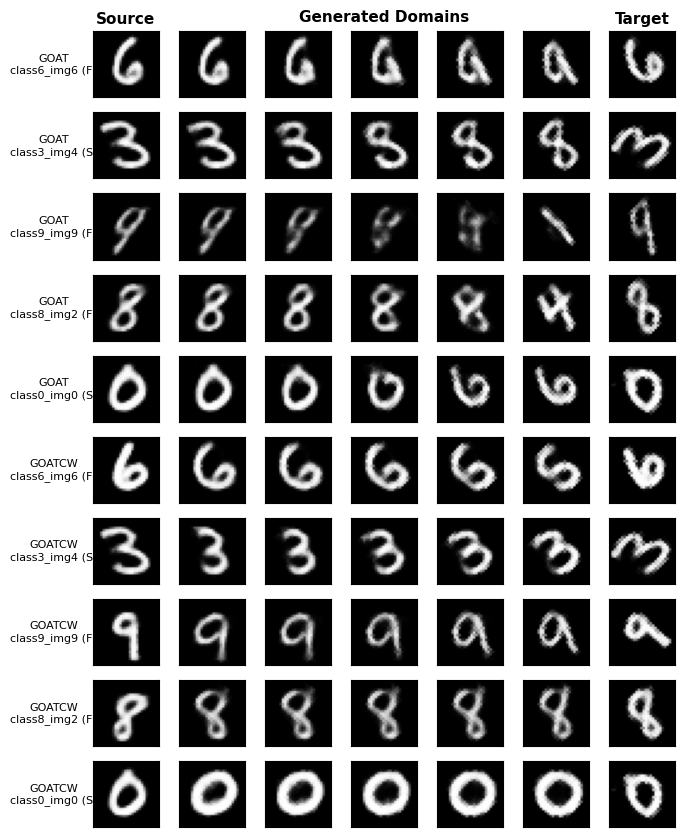

Saved: analysis_outputs/qualitative_mnist_target45_ssl0p1/seed0_feature_traj_fallback_gen5_img10_confsel/compare_GOAT_vs_GOATCW_selected3.png
Picked: [((6, 6), 'fallback'), ((3, 4), 'shared'), ((9, 9), 'fallback'), ((8, 2), 'fallback'), ((0, 0), 'shared')]


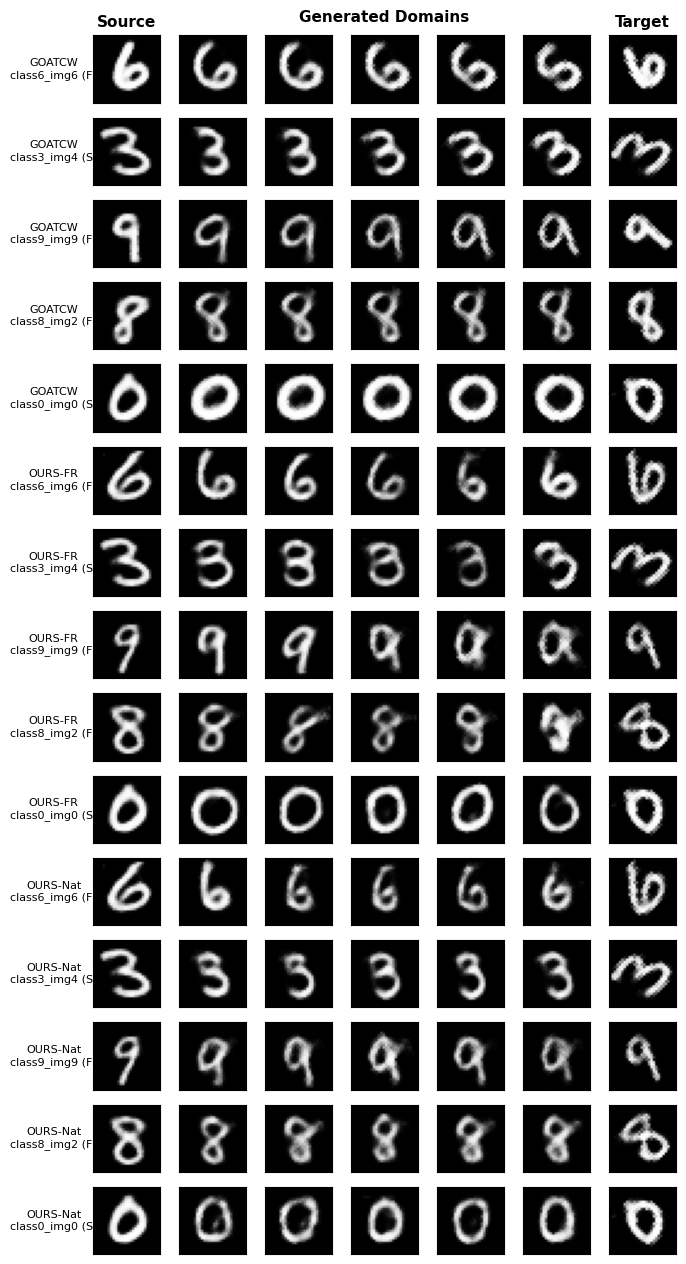

Saved: analysis_outputs/qualitative_mnist_target45_ssl0p1/seed0_feature_traj_fallback_gen5_img10_confsel/compare_GOATCW_vs_OURS_selected3.png


In [3]:
import torch, numpy as np, matplotlib.pyplot as plt
from qualitative_vae_compare import (
    _load_trajectory_cache, _common_indices_for_class, _expand_indices,
    FeatureToImageVAE, decode_features
)

RUN_DIR = "analysis_outputs/qualitative_mnist_target45_ssl0p1/seed0_feature_traj_fallback_gen5_img10_confsel"
CACHE_PATH = f"{RUN_DIR}/trajectory_cache.pt"
VAE_PATH = "analysis_outputs/qualitative_mnist_target45_ssl0p1/seed0_feature_traj_fallback_gen6_img10/feature_vae_target45_z128_ssl0p1_seed0.pt"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cache = _load_trajectory_cache(CACHE_PATH)
chains = cache["trajectory_chains"]  # dict of DomainDataset chains
labels = cache["trajectory_labels"]
methods_all = ("goat", "goat_classwise", "ours_fr", "ours_eta")

ckpt = torch.load(VAE_PATH, map_location=DEVICE, weights_only=False)
vae = FeatureToImageVAE(
    feature_dim=int(ckpt["feature_dim"]),
    latent_dim=int(ckpt["latent_dim"]),
    image_dim=28*28
).to(DEVICE)
vae.load_state_dict(ckpt["state_dict"], strict=True)
vae.eval()

# Selected trajectories from your list
selected = [(0, 0), (1, 0), (3, 4)]   # (class_id, img_i)

def get_shared_idx(cls, img_i, n_samples=10, seed=0, sample_selection="confidence"):
    idx = _common_indices_for_class(
        trajectory_chains=chains,
        methods=methods_all,
        cls=cls,
        n_samples=n_samples,
        seed=seed,
        sample_selection=sample_selection,
    )
    idx = _expand_indices(idx, n_samples, seed=seed + 12000 + cls)
    if len(idx) == 0:
        return None
    return int(idx[min(img_i, len(idx)-1)])


plot_compare(
    method_keys=["goat", "goat_classwise"],
    method_names=["GOAT", "GOATCW"],
    out_name="compare_GOAT_vs_GOATCW_selected3.png",
)

plot_compare(
    method_keys=["goat_classwise", "ours_fr", "ours_eta"],
    method_names=["GOATCW", "OURS-FR", "OURS-Nat"],
    out_name="compare_GOATCW_vs_OURS_selected3.png",
)


In [4]:
import numpy as np, torch
import importlib, qualitative_vae_compare
importlib.reload(qualitative_vae_compare)

from qualitative_vae_compare import (
    _per_method_indices_for_class,
    save_screenshot_style_grid,
    ScreenshotStyle,
    decode_features,
)

# Updated method labels
METHODS = [
    ("goat", "GOAT"),
    ("goat_classwise", "CGDA-Wass"),
    ("ours_fr", "CGDA-FR"),
    ("ours_eta", "CGDA-Nat"),
]

candidate_pairs = [(1,0), (0,0), (3,4), (6,6), (8,2), (9,9)]

def pick_indices_for_method(method_key, n_pick=5, seed=42):
    picked = []
    for cls, img_i in candidate_pairs:
        pm = _per_method_indices_for_class(
            trajectory_chains=chains,
            methods=[method_key],
            cls=cls,
            n_samples=10,
            seed=0,
            sample_selection="confidence",
        )
        arr = pm.get(method_key, np.array([], dtype=np.int64))
        if len(arr) == 0:
            print(f"[{method_key}] skip class{cls}_img{img_i}: no index")
            continue
        j = min(img_i, len(arr)-1)
        picked.append((cls, img_i, int(arr[j])))

    assert len(picked) > 0, f"No usable candidates for {method_key}"
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(picked))
    picked = [picked[i] for i in order[:min(n_pick, len(picked))]]
    return picked

def export_one_method(method_key, method_name, n_pick=5):
    picked = pick_indices_for_method(method_key, n_pick=n_pick, seed=42)
    print(method_name, "picked:", [(c, i) for c, i, _ in picked])

    chain = chains[method_key]
    n_cols = len(chain)

    src_feats = torch.stack([chain[0].data[idx] for _, _, idx in picked], dim=0)
    tgt_feats = torch.stack([chain[-1].data[idx] for _, _, idx in picked], dim=0)
    inter_feats_list = [
        torch.stack([chain[c].data[idx] for _, _, idx in picked], dim=0)
        for c in range(1, n_cols-1)
    ]

    source_imgs = decode_features(vae, src_feats)
    inter_imgs_list = [decode_features(vae, f) for f in inter_feats_list]
    target_imgs = decode_features(vae, tgt_feats)

    out = f"{RUN_DIR}/screenshot_{method_key}_selected{len(picked)}.png"


    # style = ScreenshotStyle(
    #     header_fontfamily="serif",
    #     title_fontfamily="serif",
    #     header_fontsize=10,
    #     title_fontsize=12,
    #     header_weight="normal",
    #     title_weight="normal",
    #     # shade_groups=True,          # set False for no shading at all
    #     # intermediate_gradient=True # keep minimal ink
    #         intermediate_gradient_gamma=1.0,   # shape of transition
    # shade_groups=True,                 # keep background panels enabled
    # )
    style = ScreenshotStyle(
        source_panel="#d9e8f6",     # blue
        target_panel="#f7d7d7",     # pink
        mid_panel="#efefef",
        shade_groups=True,
        intermediate_gradient=True,
        intermediate_gradient_gamma=1.0,
        header_fontsize=10,
        title_fontsize=12,
    )



    save_screenshot_style_grid(
        save_path=out,
        source_imgs=source_imgs,
        inter_imgs_list=inter_imgs_list,
        target_imgs=target_imgs,
        headers=("Source", "Generated Intermediate", "Target"),
        plot_title=method_name,   # <- add method title
        style=style,
        tile_size_in=0.42,
        h_gap_in=0.07,
        v_gap_in=0.07,
        group_gap_in=0.07,
        tint_intermediate=True,
    )
    print("Saved:", out)

for mk, mn in METHODS:
    export_one_method(mk, mn, n_pick=5)


GOAT picked: [(6, 6), (3, 4), (9, 9), (8, 2), (0, 0)]


Saved: analysis_outputs/qualitative_mnist_target45_ssl0p1/seed0_feature_traj_fallback_gen5_img10_confsel/screenshot_goat_selected5.png
CGDA-Wass picked: [(6, 6), (3, 4), (9, 9), (8, 2), (0, 0)]
Saved: analysis_outputs/qualitative_mnist_target45_ssl0p1/seed0_feature_traj_fallback_gen5_img10_confsel/screenshot_goat_classwise_selected5.png
CGDA-FR picked: [(6, 6), (3, 4), (9, 9), (8, 2), (0, 0)]
Saved: analysis_outputs/qualitative_mnist_target45_ssl0p1/seed0_feature_traj_fallback_gen5_img10_confsel/screenshot_ours_fr_selected5.png
CGDA-Nat picked: [(6, 6), (3, 4), (9, 9), (8, 2), (0, 0)]
Saved: analysis_outputs/qualitative_mnist_target45_ssl0p1/seed0_feature_traj_fallback_gen5_img10_confsel/screenshot_ours_eta_selected5.png


screenshot_goat_selected5.png


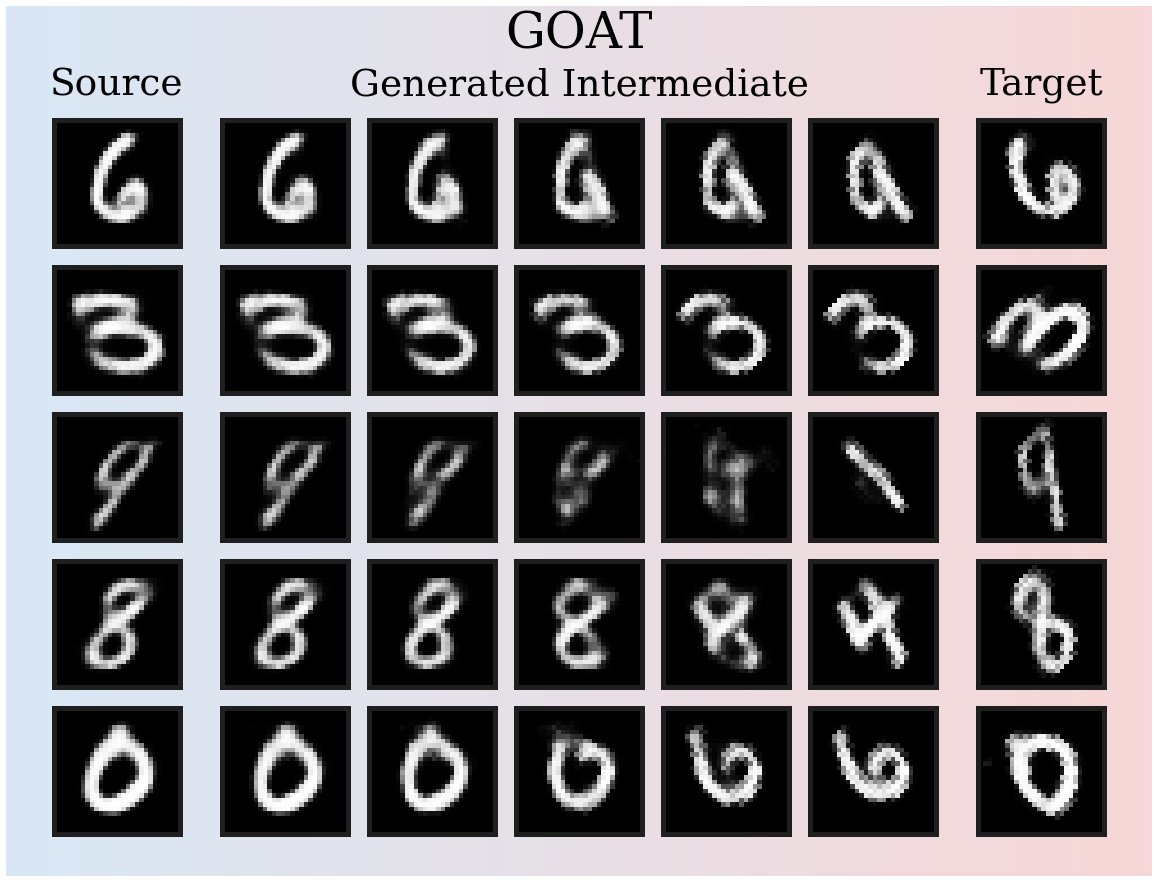

screenshot_goat_classwise_selected5.png


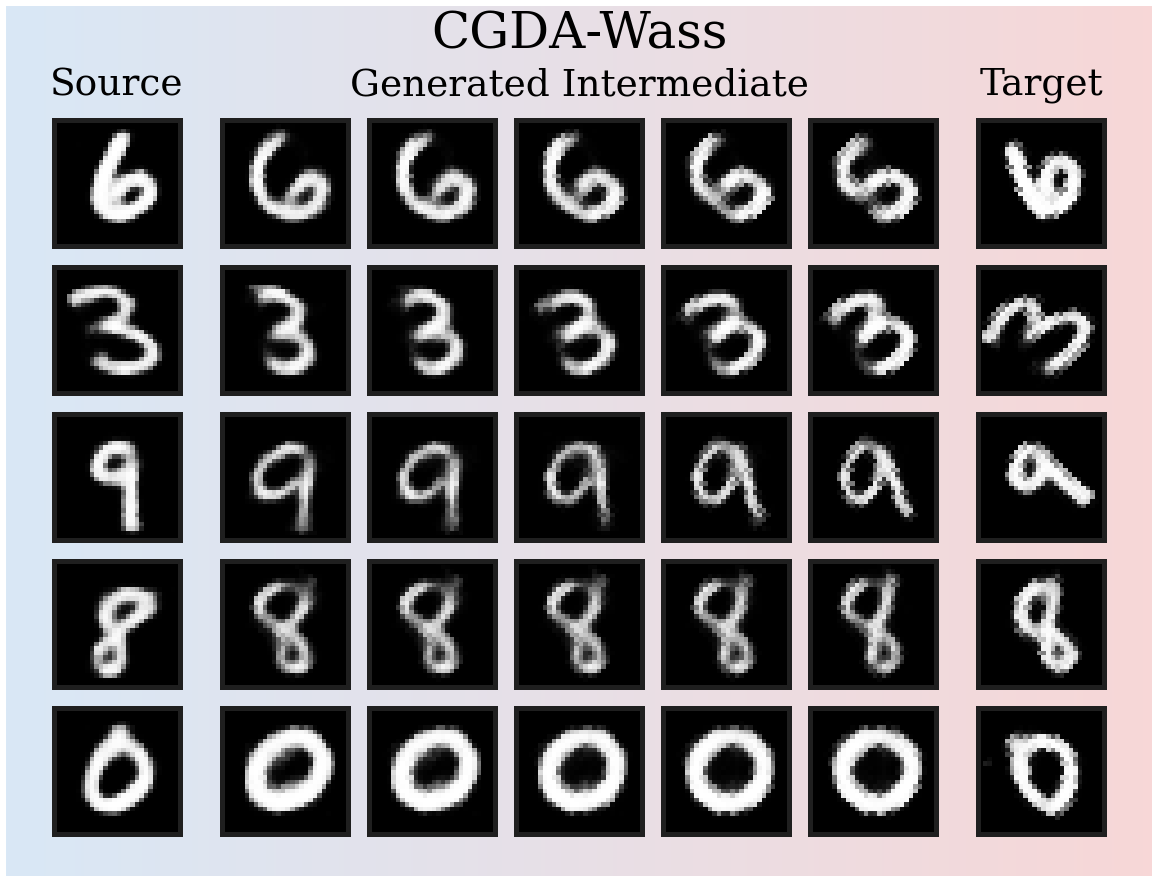

screenshot_ours_fr_selected5.png


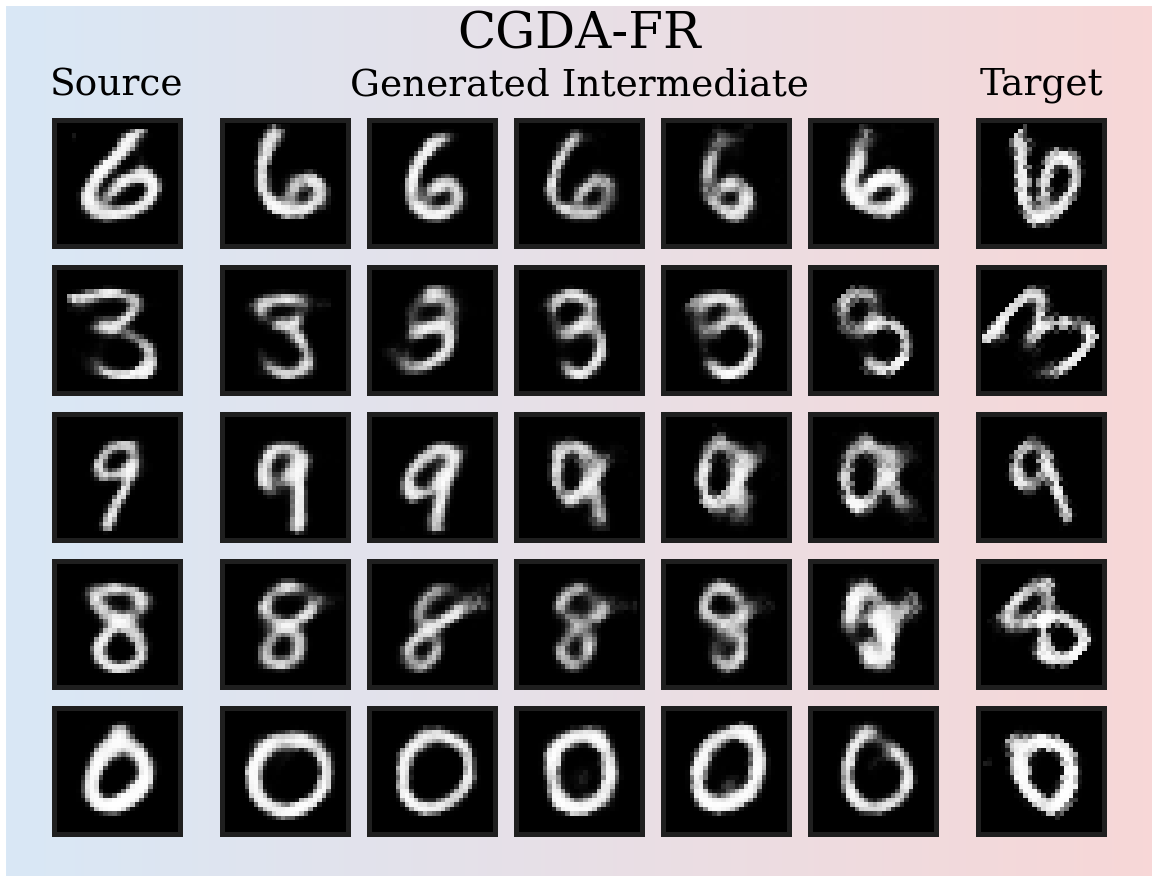

screenshot_ours_eta_selected5.png


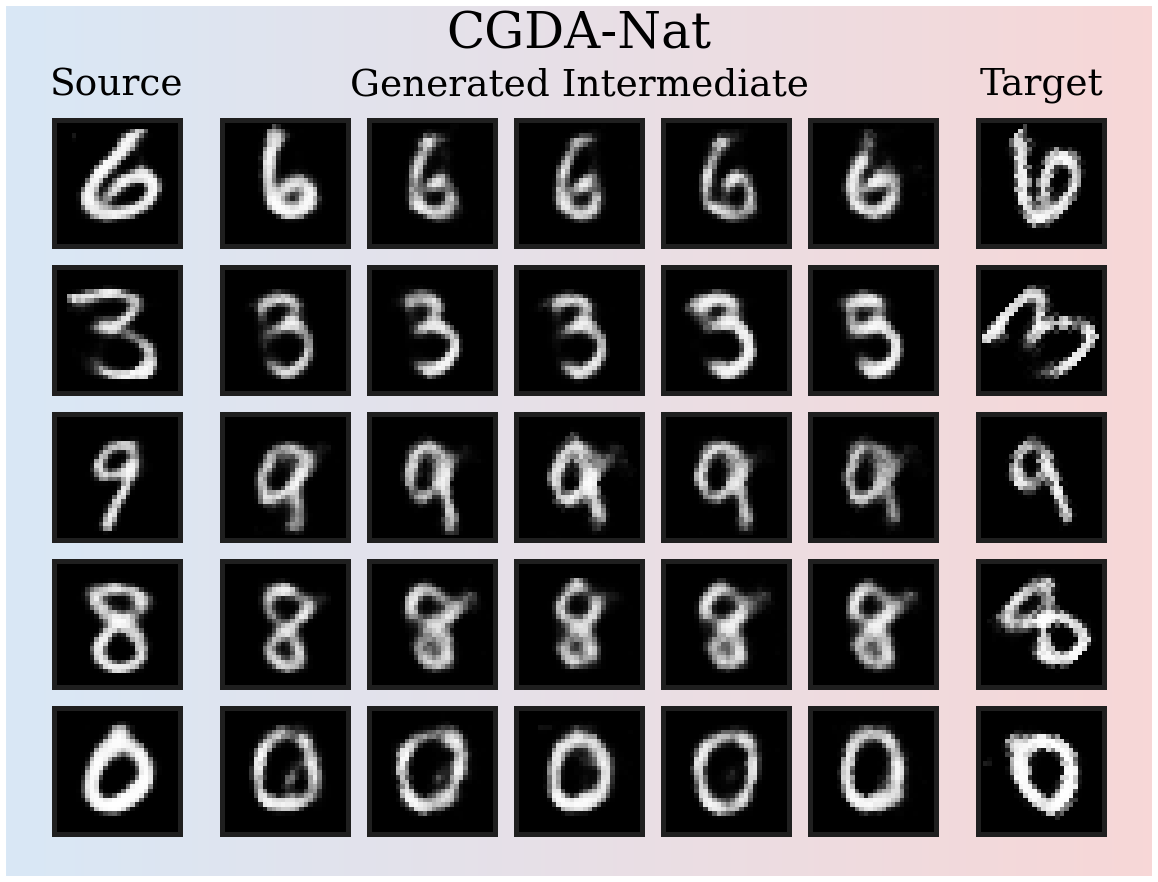

In [5]:
from pathlib import Path
from IPython.display import display, Image

RUN_DIR = Path("analysis_outputs/qualitative_mnist_target45_ssl0p1/seed0_feature_traj_fallback_gen5_img10_confsel")

files = [
    RUN_DIR / "screenshot_goat_selected5.png",
    RUN_DIR / "screenshot_goat_classwise_selected5.png",
    RUN_DIR / "screenshot_ours_fr_selected5.png",
    RUN_DIR / "screenshot_ours_eta_selected5.png",
]

for p in files:
    if p.exists():
        print(p.name)
        display(Image(filename=str(p), width=700))
    else:
        print("Missing:", p)

